# Are the four design decisions worth keeping?

Dataset: **NCI-1 full** (TrustAGI-Lab `NCI_full/1total-connect.sdf`) — 37,349 graphs, 1,793 active
(4.80%), IR ≈ 19.8:1. WL(2), attributed, 14,790 unique subtrees. **WL feature extraction only.**

Protocol for every number: vocabulary is refit **inside each training fold** (it reads the labels,
so fitting it on the full set leaks test labels), then a plain logistic probe on the WL count
vectors. 5-fold stratified. No dictionary learning.

| # | decision | verdict |
|---|---|---|
| 1 | per-class normalised DF (`df_c / n_c`) | **keep — load-bearing.** Without it the score collapses onto plain frequency (PR-AUC 0.352 vs 0.415) |
| 2 | discriminative score (Hellinger on `p_c`) | **keep — this is where all the gain comes from.** PR-AUC 0.422 vs 0.371 for frequency, same budget |
| 3 | `final = presence × discriminative` | **keep, but weaken the claim.** It is a mild frequency prior, not a noise filter — the discriminative term *already* suppresses rare tokens. Net effect ≈ 0 (MCC +0.006, PR-AUC −0.006) |
| 4 | trim at `mean − std` | **drop.** On real data the threshold is negative → keeps 100% of tokens. Your decile hyper-parameter is the correct replacement; the sweep in §4 says pick the top ~30% |

## Setup — load, hash (using the project's actual `WL` / `WeisfeilerLehmanHashing`), and compute the token table

In [23]:
import os
import networkx as nx
from rdkit import Chem

In [24]:
def load_nci_full(id=1):
    """
    id - (1, 33, 41, 47, 81, 83, 109, 123, 145)
    """
    print('Loading NCI dataset')
    DATASET_DIR = "datasets/NCI_full"  # change this
    graphs = []
    y = []

    filename = f"{id}total-connect.sdf"
    filepath = os.path.join(DATASET_DIR, filename)

    supplier = Chem.SDMolSupplier(filepath, removeHs=False)
    for mol in supplier:
        if mol is None:
            continue

        G = nx.Graph()

        # Add atoms as nodes
        for atom in mol.GetAtoms():
            G.add_node(
                atom.GetIdx(),
                feature=atom.GetSymbol()   # WL uses node labels
            )

        # Add bonds as edges
        for bond in mol.GetBonds():
            G.add_edge(
                bond.GetBeginAtomIdx(),
                bond.GetEndAtomIdx(),
                bond_type=str(bond.GetBondType()),
                bond_order=bond.GetBondTypeAsDouble(),
                aromatic=bond.GetIsAromatic(),
                in_ring=bond.IsInRing(),
                conjugated=bond.GetIsConjugated(),
                stereo=str(bond.GetStereo())
            )

        # Get graph label
        # In NCI, class label is stored as a molecule property
        label = int(float(mol.GetProp("value")))
        graphs.append(G)
        y.append(label)

    print(f"Loaded {len(graphs)} graphs")
    return graphs, y

In [25]:
import hashlib, io, os, time, urllib.request, zipfile
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
import pandas as pd
from scipy.sparse import csr_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (average_precision_score, balanced_accuracy_score,
                             f1_score, matthews_corrcoef, roc_auc_score)

from graph_encoders.wl import WL

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .25})

# Use the project's own WL implementation (graph_encoders/wl.py +
# graph_encoders/wlkernalsubtree.py) instead of the ad-hoc wl() function, so
# every plot/verdict below reflects the code actually used elsewhere in the
# project. erase_base_features=False keeps the depth-0 (raw atom label) token
# in the corpus, matching the original exploratory wl().
wl_encoder = WL()

t0 = time.time()
graphs, y = load_nci_full(1)
y = np.array(y)

Loading NCI dataset


[19:29:28] Explicit valence for atom # 1 Cl, 1, is greater than permitted
[19:29:28] ERROR: Could not sanitize molecule ending on line 5976
[19:29:28] ERROR: Explicit valence for atom # 1 Cl, 1, is greater than permitted
[19:29:28] Explicit valence for atom # 0 Br, 1, is greater than permitted
[19:29:28] ERROR: Could not sanitize molecule ending on line 9488
[19:29:28] ERROR: Explicit valence for atom # 0 Br, 1, is greater than permitted
[19:29:28] Explicit valence for atom # 1 Cl, 1, is greater than permitted
[19:29:28] ERROR: Could not sanitize molecule ending on line 12926
[19:29:28] ERROR: Explicit valence for atom # 1 Cl, 1, is greater than permitted
[19:29:28] Explicit valence for atom # 1 Cl, 1, is greater than permitted
[19:29:28] ERROR: Could not sanitize molecule ending on line 13981
[19:29:28] ERROR: Explicit valence for atom # 1 Cl, 1, is greater than permitted
[19:29:28] Explicit valence for atom # 1 Cl, 1, is greater than permitted
[19:29:28] ERROR: Could not sanitize mol

Loaded 36937 graphs


In [26]:
documents = wl_encoder.create_wl_hash(graphs)
corpus = [doc.words for doc in documents]
HASH_TABLE = wl_encoder.hash_table  # token -> (depth, human-readable signature)

In [27]:
N1, N0 = int((y == 1).sum()), int((y == -1).sum())
print(f"{len(graphs):,} graphs | {N1:,} active ({100*N1/len(y):.2f}%) | {N0:,} active ({100*N0/len(y):.2f}%) | IR {N0/N1:.1f}:1 "
      f"| {len(HASH_TABLE):,} unique WL subtrees | {time.time()-t0:.0f}s")

36,937 graphs | 1,734 active (4.69%) | 35,203 active (95.31%) | IR 20.3:1 | 13,527 unique WL subtrees | 109s


In [28]:
idx = np.arange(len(y))
cdf = {-1: Counter(), 1: Counter()}
tf  = Counter()
for i in idx:
    tf.update(corpus[i])
    cdf[y[i]].update(set(corpus[i]))
n = {c: int((y[idx] == c).sum()) for c in (-1, 1)}

In [29]:
idx

array([    0,     1,     2, ..., 36934, 36935, 36936], shape=(36937,))

In [30]:
cdf

{-1: Counter({'14cdfa9421205f7d751ae1fd8bbc1812': 33324,
          '0100b3e546d5ca2947d4cc352b72d088': 28631,
          '75a3c0fc5b9fe767680fe9123b7c0501': 27237,
          '85afdd843f4605e6b48c7d2bd603589b': 23305,
          'eba9e7f8b4c173fa7c1885a96a1674dc': 22632,
          'ae1f9635adc66c91411e8f77e79b3523': 21072,
          '25598f48381cbc94402c360cc14c65a0': 19080,
          '906cec4ee868948aa03cee2550a89333': 18934,
          '8db910500404fcf6f2f3bf4a86dcee9e': 18004,
          'eb5d7020ad85d702f9f4a48b72bf911e': 17515,
          'e6aa35104b7070c37a9ce84f8dea22bb': 14870,
          'e252a26cae05e5009cec9ee7647b14e8': 14598,
          'fe2d32b7e5d9a765f7b1f8f463636a28': 14245,
          '424e91c0cf319b05ddbfb7b77842123d': 12782,
          'af3e62d65d46a9f16366be9e4b1e8143': 11334,
          '091c2baa8ae53fc073381e5aef62e50c': 11272,
          '5157df0d51458b32f775b2c92adc523b': 10041,
          'dbe41cfe2ede3ab76964a4632a78138a': 9687,
          'f14c13cd6974bfe51396472f3b4fa1fb

In [31]:
tf

Counter({'14cdfa9421205f7d751ae1fd8bbc1812': 287066,
         '0100b3e546d5ca2947d4cc352b72d088': 90659,
         'ae1f9635adc66c91411e8f77e79b3523': 83227,
         '75a3c0fc5b9fe767680fe9123b7c0501': 72066,
         '85afdd843f4605e6b48c7d2bd603589b': 71091,
         '906cec4ee868948aa03cee2550a89333': 53160,
         'eba9e7f8b4c173fa7c1885a96a1674dc': 51932,
         '8db910500404fcf6f2f3bf4a86dcee9e': 47296,
         'eb5d7020ad85d702f9f4a48b72bf911e': 40385,
         '25598f48381cbc94402c360cc14c65a0': 37464,
         'e6aa35104b7070c37a9ce84f8dea22bb': 32714,
         'e252a26cae05e5009cec9ee7647b14e8': 31489,
         'fe2d32b7e5d9a765f7b1f8f463636a28': 23637,
         'af3e62d65d46a9f16366be9e4b1e8143': 22995,
         '424e91c0cf319b05ddbfb7b77842123d': 20662,
         'f14c13cd6974bfe51396472f3b4fa1fb': 18264,
         'dbe41cfe2ede3ab76964a4632a78138a': 17600,
         '5157df0d51458b32f775b2c92adc523b': 17040,
         '091c2baa8ae53fc073381e5aef62e50c': 16465,
         '2

In [32]:
n

{-1: 35203, 1: 1734}

In [33]:
w   = list(tf)
df0 = np.array([cdf[-1][t] for t in w], float)
df1 = np.array([cdf[1][t] for t in w], float)

In [34]:
df0

array([5.5890e+03, 4.6320e+03, 1.7515e+04, ..., 1.0000e+00, 1.0000e+00,
       1.0000e+00], shape=(13467,))

In [35]:
def token_table(idx):
    cdf = {-1: Counter(), 1: Counter()}
    tf  = Counter()
    for i in idx:
        tf.update(corpus[i])
        cdf[y[i]].update(set(corpus[i]))
    n = {c: int((y[idx] == c).sum()) for c in (-1, 1)}
    N = len(idx)

    w   = list(tf)
    df0 = np.array([cdf[-1][t] for t in w], float)
    df1 = np.array([cdf[1][t] for t in w], float)

    p0, p1 = df0 / n[-1], df1 / n[1]                  # (1) per-class normalised frequency
    disc   = np.abs(np.sqrt(p0) - np.sqrt(p1))       # (2) discriminative score
    signed_disc = np.sqrt(p0) - np.sqrt(p1)
    pres   = p0 + p1                                 #  total presence
    final  = pres * disc                             # (3) final score

    q0, q1 = df0 / N, df1 / N                        # counterfactual for (1): normalise by corpus
    # final_unnorm = ((q0 + q1) / 2) * np.abs(np.sqrt(q0) - np.sqrt(q1))

    return pd.DataFrame(dict(
        token=w, depth=[HASH_TABLE[t][-1] for t in w], signature=[HASH_TABLE[t][1] for t in w],
        tf=[tf[t] for t in w], df=df0 + df1, df0=df0, df1=df1, p0=p0, p1=p1,
        disc=disc, signed_disc= signed_disc, presence=pres, final=final,
        favours=np.where(p1 > p0, 1, -1)))


stats = token_table(np.arange(len(y)))
# print(f"{len(stats):,} tokens | {(stats.df == 1).mean()*100:.0f}% occur in a single graph "
#       f"| {(stats.favours == 1).sum():,} favour the active class")

In [36]:
stats

,token,depth,signature,tf,df,df0,df1,p0,p1,disc,signed_disc,presence,final,favours
0,177a3f3e17756975572a209510000216,"Cl[C,Cl]","Cl[C,Cl]",9077,5807.0,5589.0,218.0,0.158765,0.125721,0.043882,0.043882,0.284486,1.248372e-02,-1
1,34f2086393adc8edbf1eb8d7921e73e2,"Cl[C,Cl][C[C,C,C,Cl],Cl[C,Cl]]","Cl[C,Cl][C[C,C,C,Cl],Cl[C,Cl]]",6983,4746.0,4632.0,114.0,0.131580,0.065744,0.106333,0.106333,0.197324,2.098208e-02,-1
2,eb5d7020ad85d702f9f4a48b72bf911e,"O[C,C,O]","O[C,C,O]",40385,18644.0,17515.0,1129.0,0.497543,0.651096,0.101538,-0.101538,1.148639,1.166303e-01,1
3,9b97fa3346b5bf85efa8c628724b0c08,"O[C,C,O][C[C,C,C,C,O],C[C,C,C,O],O[C,C,O]]","O[C,C,O][C[C,C,C,C,O],C[C,C,C,O],O[C,C,O]]",500,461.0,405.0,56.0,0.011505,0.032295,0.072449,-0.072449,0.043800,3.173259e-03,1
4,9c43308fd585e1590306f00e9a771367,"O[C,C,O][C[C,C,C,O],C[C,C,O,O],O[C,C,O]]","O[C,C,O][C[C,C,C,O],C[C,C,O,O],O[C,C,O]]",6815,3709.0,3297.0,412.0,0.093657,0.237601,0.181409,-0.181409,0.331258,6.009322e-02,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13462,6ba0ea7073fdab59df750a8af0536967,"C[C,C,S][C[C,C,N],C[C,C,S],S[C,P,S]]","C[C,C,S][C[C,C,N],C[C,C,S],S[C,P,S]]",1,1.0,1.0,0.0,0.000028,0.000000,0.005330,0.005330,0.000028,1.514016e-07,-1
13463,7f1af608829f390f7264caf496dc14b8,"S[C,C,N,O,S][C[C,C,S],C[C,C,S],N[N,S],O[O,S],S...","S[C,C,N,O,S][C[C,C,S],C[C,C,S],N[N,S],O[O,S],S...",1,1.0,1.0,0.0,0.000028,0.000000,0.005330,0.005330,0.000028,1.514016e-07,-1
13464,6d9e49eb2cdb4d5002d158f1af8a5467,"C[C,C,C,C,N][C[C,C,C,C,N],C[C,C,C],C[C,C,F,F],...","C[C,C,C,C,N][C[C,C,C,C,N],C[C,C,C],C[C,C,F,F],...",1,1.0,1.0,0.0,0.000028,0.000000,0.005330,0.005330,0.000028,1.514016e-07,-1
13465,1f99baf960a64fe2717b3db974801551,"C[C,C,C][C[C,C,C],C[C,C,Cl],C[C,C,O,O]]","C[C,C,C][C[C,C,C],C[C,C,Cl],C[C,C,O,O]]",1,1.0,1.0,0.0,0.000028,0.000000,0.005330,0.005330,0.000028,1.514016e-07,-1


---
## Plot 1 — Top Frequent Vs. Discriminative Score only Vs. Final Score

Every dot is one WL subtree. 

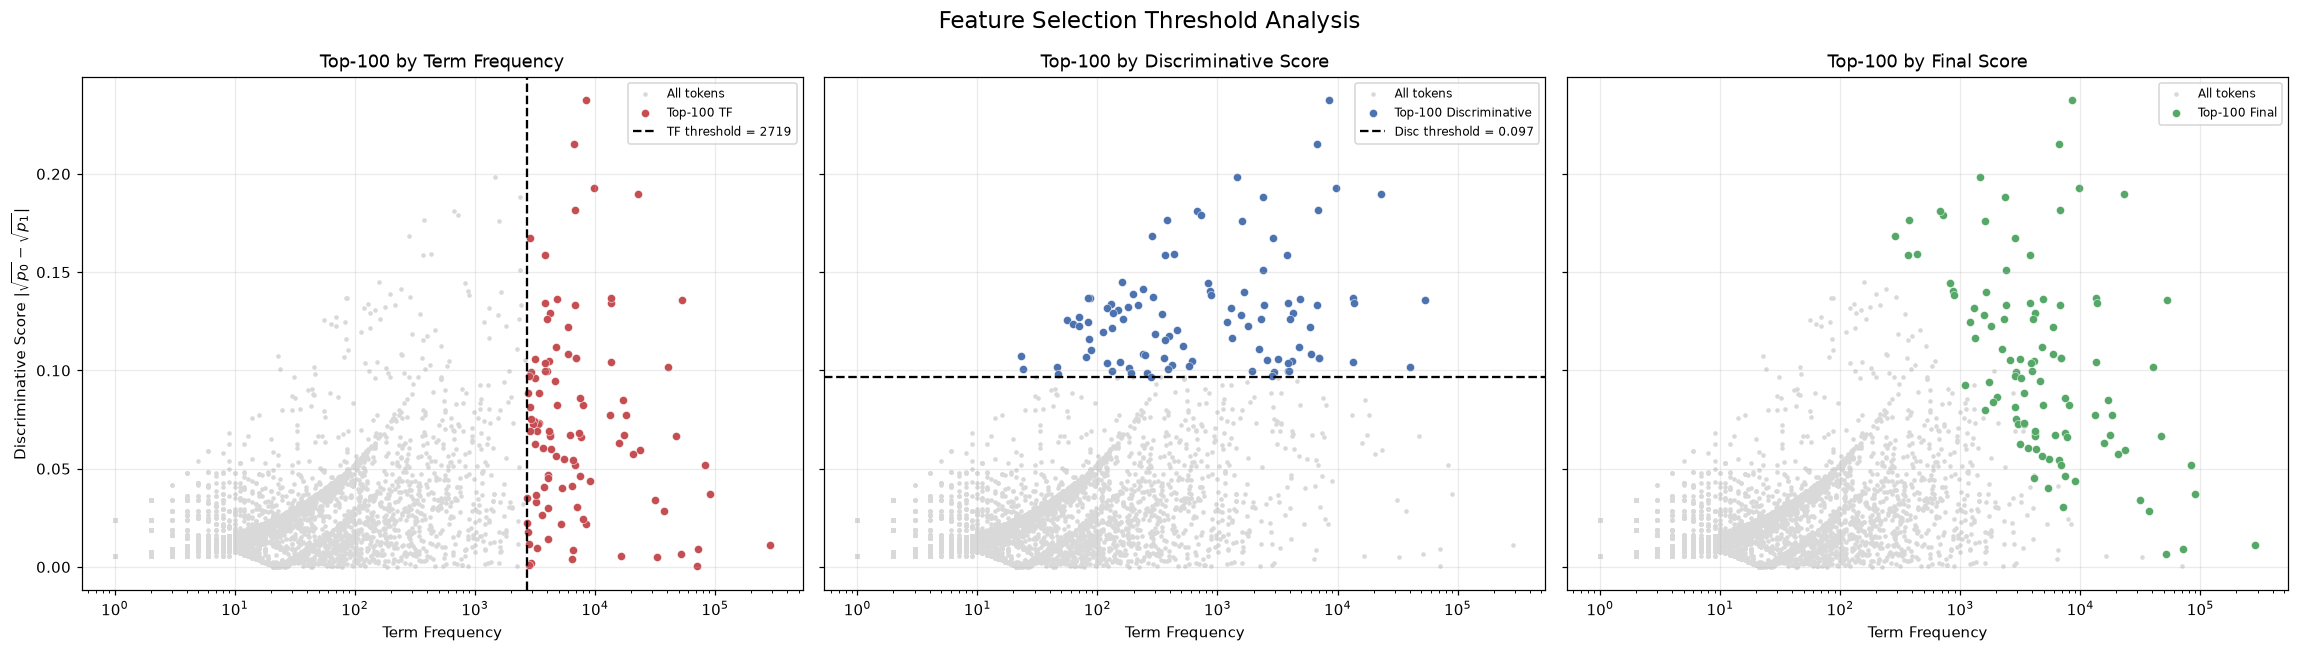

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6), sharey=True)

# ---------- Graph 1: TF ----------
ax = axes[0]

ax.scatter(
    stats.tf,
    stats.disc,
    s=4,
    c="#d9d9d9",
    label="All tokens"
)

top_tf = stats.nlargest(100, "tf")

ax.scatter(
    top_tf.tf,
    top_tf.disc,
    s=28,
    c="#C44E52",
    edgecolors="white",
    linewidths=0.3,
    label="Top-100 TF"
)

# TF threshold
tf_threshold = top_tf.tf.min()

ax.axvline(
    tf_threshold,
    linestyle="--",
    linewidth=1.5,
    color="black",
    label=f"TF threshold = {tf_threshold}"
)

ax.set_xscale("log")
ax.set_xlabel("Term Frequency")
ax.set_ylabel(r"Discriminative Score $|\sqrt{p_0}-\sqrt{p_1}|$")
ax.set_title("Top-100 by Term Frequency")
ax.legend(fontsize=8)



# ---------- Graph 2: Discriminative ----------
ax = axes[1]

ax.scatter(
    stats.tf,
    stats.disc,
    s=4,
    c="#d9d9d9",
    label="All tokens"
)

top_disc = stats.nlargest(100, "disc")

ax.scatter(
    top_disc.tf,
    top_disc.disc,
    s=28,
    c="#4C72B0",
    edgecolors="white",
    linewidths=0.3,
    label="Top-100 Discriminative"
)

# Discriminative threshold
disc_threshold = top_disc.disc.min()

ax.axhline(
    disc_threshold,
    linestyle="--",
    linewidth=1.5,
    color="black",
    label=f"Disc threshold = {disc_threshold:.3f}"
)

ax.set_xscale("log")
ax.set_xlabel("Term Frequency")
ax.set_title("Top-100 by Discriminative Score")
ax.legend(fontsize=8)



# ---------- Graph 3: Final ----------
ax = axes[2]

ax.scatter(
    stats.tf,
    stats.disc,
    s=4,
    c="#d9d9d9",
    label="All tokens"
)

top_final = stats.nlargest(100, "final")

ax.scatter(
    top_final.tf,
    top_final.disc,
    s=28,
    c="#55A868",
    edgecolors="white",
    linewidths=0.3,
    label="Top-100 Final"
)

ax.set_xscale("log")
ax.set_xlabel("Term Frequency")
ax.set_title("Top-100 by Final Score")
ax.legend(fontsize=8)


plt.suptitle(
    "Feature Selection Threshold Analysis",
    fontsize=15
)

plt.tight_layout()
plt.show()

# print(stats.assign(rank_by=lambda d: None).pipe(lambda _: pd.DataFrame({
#     "selection": ["frequency (legacy)", "discriminative only", "final score (ours)"],
#     "median df of top-100":  [stats.nlargest(100, c).df.median()   for c in ["tf", "disc", "final"]],
#     "mean disc. of top-100": [stats.nlargest(100, c).disc.mean()   for c in ["tf", "disc", "final"]],
#     "% favouring active":    [100*(stats.nlargest(100, c).favours == 1).mean() for c in ["tf", "disc", "final"]],
# })).round(3).to_string(index=False))

`mean − std` is **negative** because the score distribution is heavy-tailed (`std` is 13× `mean`),
so every token passes and no trimming happens. It is not a tuning problem — with a right-skewed
distribution this rule can never trim. Worse, `self.n_vocab = len(trimmed_vocab)` then rewrites the
hyper-parameter to 14,790 and `calc_coefficients` tries `np.zeros((37349, 14790))` = **4.4 GB**.

Your proposed replacement (vocabulary size as an explicit hyper-parameter / decile) is the right
call. The sweep below tells you which decile to pick. **Slow cell (~4 min).**

---
The absolute value in `|sqrt(p1) - sqrt(p0)|` throws away *which* class a subtree points at. Drop
the absolute value and the score becomes **signed**:

$$ s(w) \;=\; \sqrt{p_{\text{active}}(w)} - \sqrt{p_{\text{inactive}}(w)} $$

* `s < 0` -> the subtree is enriched in the **majority** (inactive) class
* `s > 0` -> the subtree is enriched in the **minority** (active) class

Horizontal axis = signed score, vertical axis = total frequency. Grey = every WL subtree;
coloured = the 1000 subtrees each rule actually keeps.

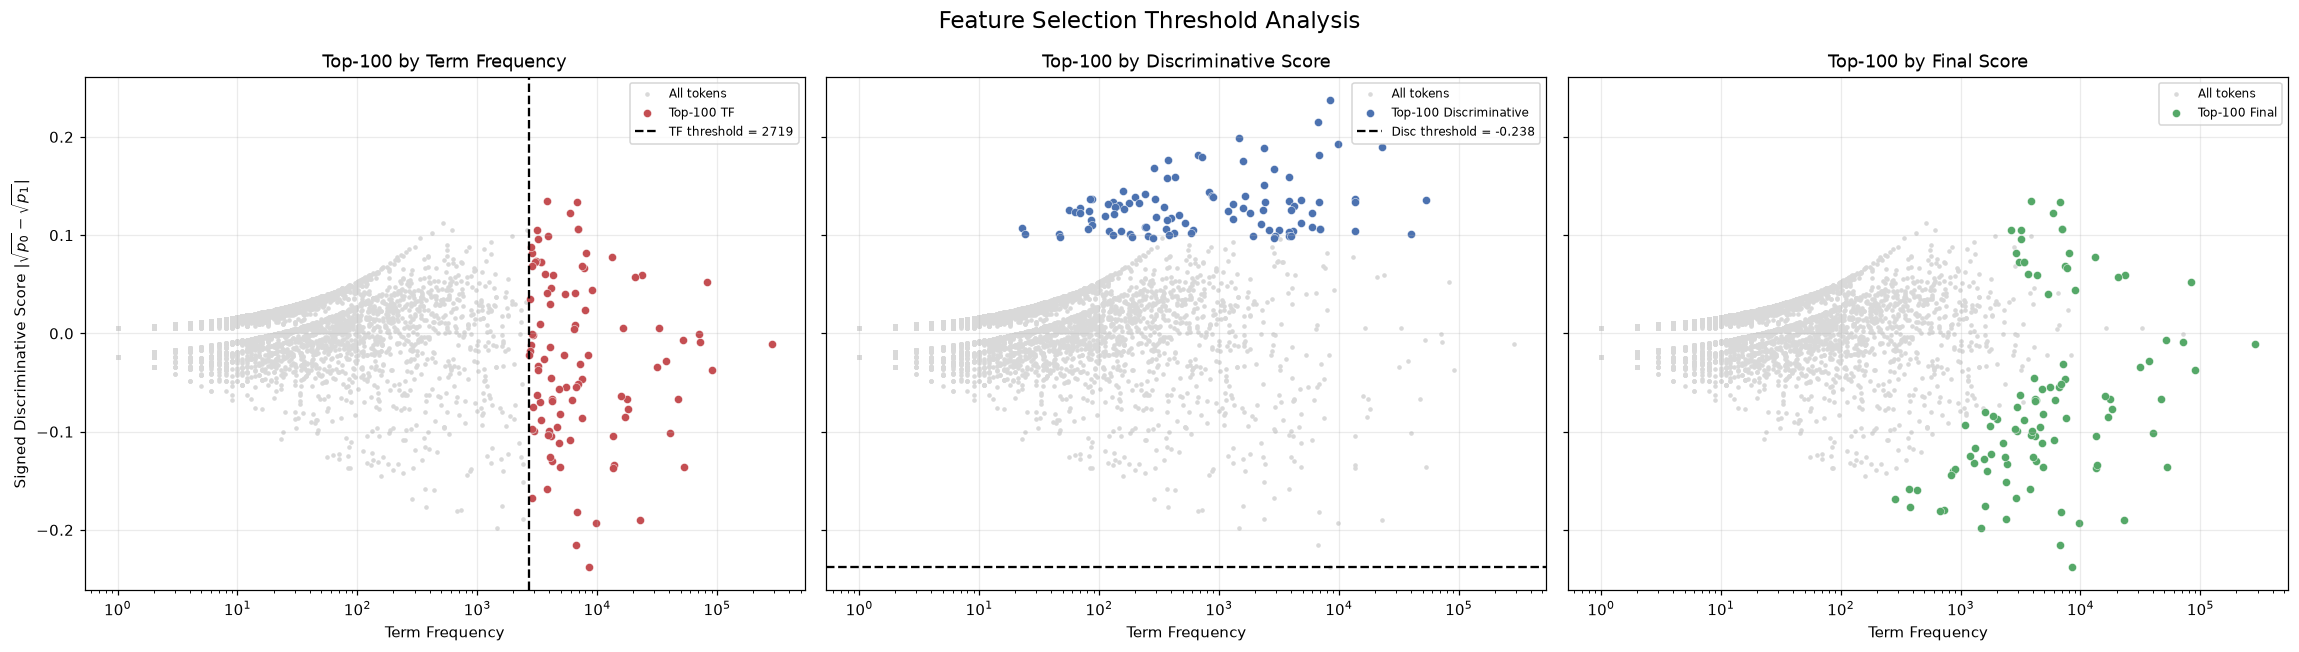

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6), sharey=True)

# ---------- Graph 1: TF ----------
ax = axes[0]

ax.scatter(
    stats.tf,
    stats.signed_disc,
    s=4,
    c="#d9d9d9",
    label="All tokens"
)

top_tf = stats.nlargest(100, "tf")

ax.scatter(
    top_tf.tf,
    top_tf.signed_disc,
    s=28,
    c="#C44E52",
    edgecolors="white",
    linewidths=0.3,
    label="Top-100 TF"
)

# TF threshold
tf_threshold = top_tf.tf.min()

ax.axvline(
    tf_threshold,
    linestyle="--",
    linewidth=1.5,
    color="black",
    label=f"TF threshold = {tf_threshold}"
)

ax.set_xscale("log")
ax.set_xlabel("Term Frequency")
ax.set_ylabel(r"Signed Discriminative Score $|\sqrt{p_0}-\sqrt{p_1}|$")
ax.set_title("Top-100 by Term Frequency")
ax.legend(fontsize=8)



# ---------- Graph 2: Discriminative ----------
ax = axes[1]

ax.scatter(
    stats.tf,
    stats.signed_disc,
    s=4,
    c="#d9d9d9",
    label="All tokens"
)

top_disc = stats.nlargest(100, "disc")

ax.scatter(
    top_disc.tf,
    top_disc.disc,
    s=28,
    c="#4C72B0",
    edgecolors="white",
    linewidths=0.3,
    label="Top-100 Discriminative"
)

# Discriminative threshold
disc_threshold = top_disc.signed_disc.min()

ax.axhline(
    disc_threshold,
    linestyle="--",
    linewidth=1.5,
    color="black",
    label=f"Disc threshold = {disc_threshold:.3f}"
)

ax.set_xscale("log")
ax.set_xlabel("Term Frequency")
ax.set_title("Top-100 by Discriminative Score")
ax.legend(fontsize=8)



# ---------- Graph 3: Final ----------
ax = axes[2]

ax.scatter(
    stats.tf,
    stats.signed_disc,
    s=4,
    c="#d9d9d9",
    label="All tokens"
)

top_final = stats.nlargest(100, "final")

ax.scatter(
    top_final.tf,
    top_final.signed_disc,
    s=28,
    c="#55A868",
    edgecolors="white",
    linewidths=0.3,
    label="Top-100 Final"
)

ax.set_xscale("log")
ax.set_xlabel("Term Frequency")
ax.set_title("Top-100 by Final Score")
ax.legend(fontsize=8)


plt.suptitle(
    "Feature Selection Threshold Analysis",
    fontsize=15
)

plt.tight_layout()
plt.show()

# print(stats.assign(rank_by=lambda d: None).pipe(lambda _: pd.DataFrame({
#     "selection": ["frequency (legacy)", "discriminative only", "final score (ours)"],
#     "median df of top-100":  [stats.nlargest(100, c).df.median()   for c in ["tf", "disc", "final"]],
#     "mean disc. of top-100": [stats.nlargest(100, c).disc.mean()   for c in ["tf", "disc", "final"]],
#     "% favouring active":    [100*(stats.nlargest(100, c).favours == 1).mean() for c in ["tf", "disc", "final"]],
# })).round(3).to_string(index=False))

,selection,kept majority-biased,kept minority-biased,% minority-biased,median signed score
0,legacy — frequency top-1000,603,397,39.7,-0.013
1,final score top-1000,459,541,54.1,0.015


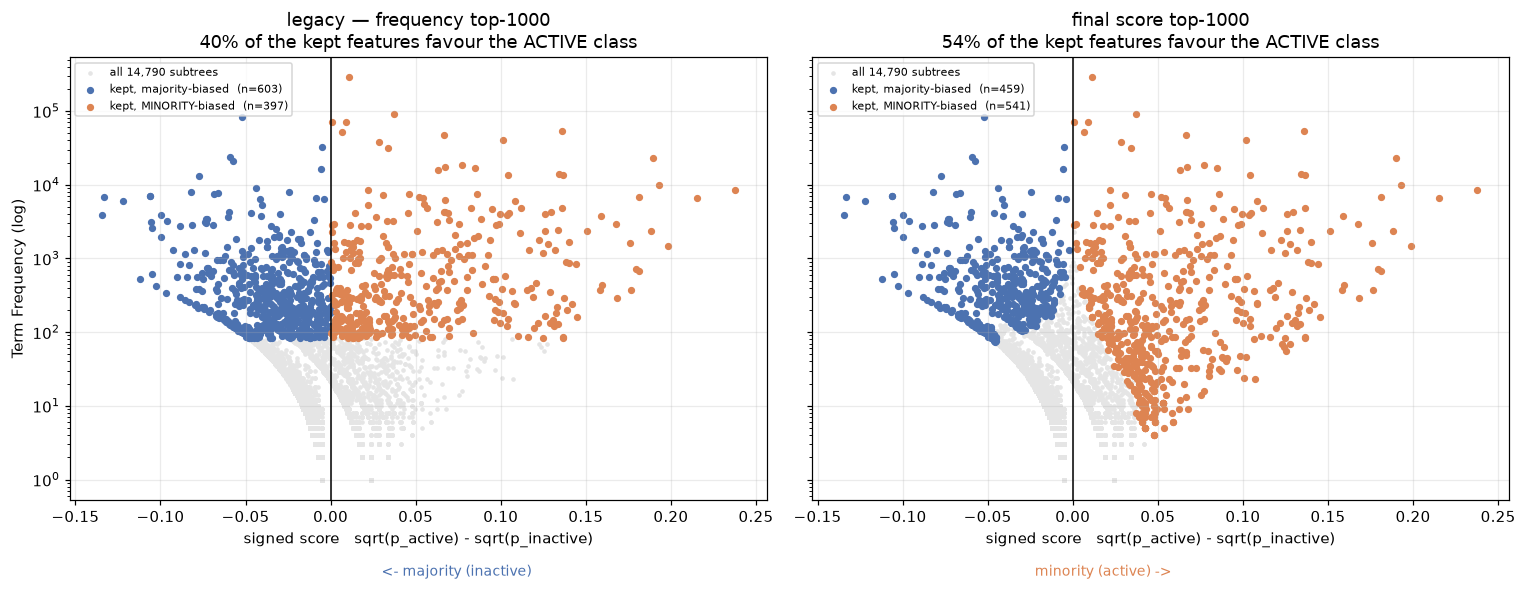

In [39]:
stats["signed"] = np.sqrt(stats.p1) - np.sqrt(stats.p0)     # no absolute value
N_VOCAB = 1000
SEL = {
    f"legacy — frequency top-{N_VOCAB}": set(stats.nlargest(N_VOCAB, "tf").token),
    f"final score top-{N_VOCAB}": set(stats.nlargest(N_VOCAB, "final").token),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.4), sharex=True, sharey=True)
for ax, (name, sel) in zip(axes, SEL.items()):
    keep = stats[stats.token.isin(sel)]
    ax.scatter(stats.signed, stats.tf, s=4, c="#e5e5e5", label="all 14,790 subtrees")
    neg, pos = keep[keep.signed < 0], keep[keep.signed >= 0]
    ax.scatter(neg.signed, neg.tf, s=14, c="#4C72B0", label=f"kept, majority-biased  (n={len(neg)})")
    ax.scatter(pos.signed, pos.tf, s=14, c="#DD8452", label=f"kept, MINORITY-biased  (n={len(pos)})")
    ax.axvline(0, c="k", lw=1)
    ax.set_yscale("log")
    ax.set_xlabel("signed score   sqrt(p_active) - sqrt(p_inactive)")
    ax.set_title(f"{name}\n{100*len(pos)/len(keep):.0f}% of the kept features favour the ACTIVE class")
    ax.legend(fontsize=7, loc="upper left")
axes[0].set_ylabel("Term Frequency (log)")
fig.text(.30, .02, "<- majority (inactive)", ha="center", fontsize=9, color="#4C72B0")
fig.text(.72, .02, "minority (active) ->", ha="center", fontsize=9, color="#DD8452")
fig.tight_layout(rect=[0, .04, 1, 1])

pd.DataFrame({
    "selection": list(SEL),
    "kept majority-biased": [int((stats[stats.token.isin(s)].signed < 0).sum()) for s in SEL.values()],
    "kept minority-biased": [int((stats[stats.token.isin(s)].signed >= 0).sum()) for s in SEL.values()],
    "% minority-biased":    [100*(stats[stats.token.isin(s)].signed >= 0).mean() for s in SEL.values()],
    "median signed score":  [stats[stats.token.isin(s)].signed.median() for s in SEL.values()],
}).round(3)

,selection,kept majority-biased,kept minority-biased,% minority-biased,median signed score
0,legacy — frequency top-224,96,128,57.143,0.012
1,final score top-224,52,172,76.786,0.076


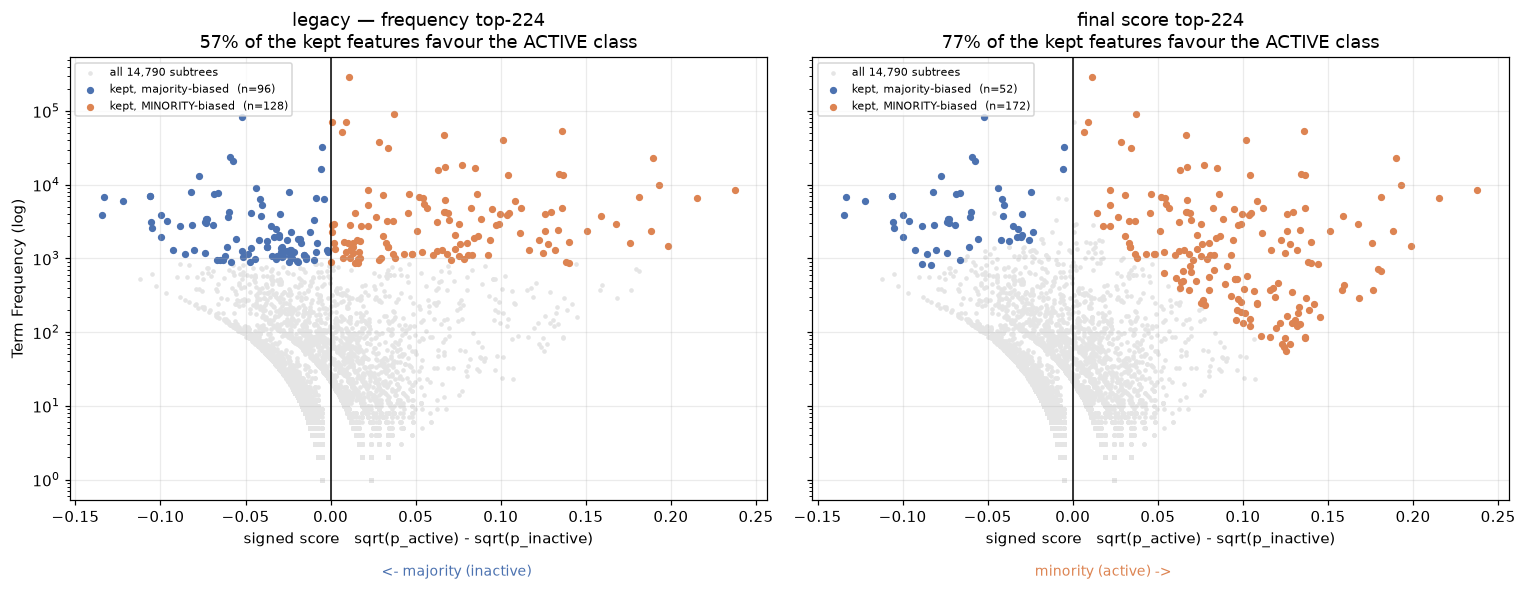

In [40]:
stats["signed"] = np.sqrt(stats.p1) - np.sqrt(stats.p0)     # no absolute value
N_VOCAB = 224
SEL = {
    f"legacy — frequency top-{N_VOCAB}": set(stats.nlargest(N_VOCAB, "tf").token),
    f"final score top-{N_VOCAB}": set(stats.nlargest(N_VOCAB, "final").token),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.4), sharex=True, sharey=True)
for ax, (name, sel) in zip(axes, SEL.items()):
    keep = stats[stats.token.isin(sel)]
    ax.scatter(stats.signed, stats.tf, s=4, c="#e5e5e5", label="all 14,790 subtrees")
    neg, pos = keep[keep.signed < 0], keep[keep.signed >= 0]
    ax.scatter(neg.signed, neg.tf, s=14, c="#4C72B0", label=f"kept, majority-biased  (n={len(neg)})")
    ax.scatter(pos.signed, pos.tf, s=14, c="#DD8452", label=f"kept, MINORITY-biased  (n={len(pos)})")
    ax.axvline(0, c="k", lw=1)
    ax.set_yscale("log")
    ax.set_xlabel("signed score   sqrt(p_active) - sqrt(p_inactive)")
    ax.set_title(f"{name}\n{100*len(pos)/len(keep):.0f}% of the kept features favour the ACTIVE class")
    ax.legend(fontsize=7, loc="upper left")
axes[0].set_ylabel("Term Frequency (log)")
fig.text(.30, .02, "<- majority (inactive)", ha="center", fontsize=9, color="#4C72B0")
fig.text(.72, .02, "minority (active) ->", ha="center", fontsize=9, color="#DD8452")
fig.tight_layout(rect=[0, .04, 1, 1])

pd.DataFrame({
    "selection": list(SEL),
    "kept majority-biased": [int((stats[stats.token.isin(s)].signed < 0).sum()) for s in SEL.values()],
    "kept minority-biased": [int((stats[stats.token.isin(s)].signed >= 0).sum()) for s in SEL.values()],
    "% minority-biased":    [100*(stats[stats.token.isin(s)].signed >= 0).mean() for s in SEL.values()],
    "median signed score":  [stats[stats.token.isin(s)].signed.median() for s in SEL.values()],
}).round(3)